In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

print("="*60)
print("Week 2 Model Results Report")
print("Project: Weather Intelligence Platform")
print("Author: Shivya | MacroEdtech | July 2026")
print("="*60)

Week 2 Model Results Report
Project: Weather Intelligence Platform
Author: Shivya | MacroEdtech | July 2026


In [2]:
baseline = pd.read_csv("../reports/baseline_results.csv")
ml_results = pd.read_csv("../reports/ml_model_results.csv")
ts_results = pd.read_csv("../reports/time_series_results.csv")
multi_city = pd.read_csv("../reports/multi_city_results.csv")

print("All result files loaded successfully!\n")

print("Baseline Models:", baseline.shape)
print("ML Results:", ml_results.shape)
print("Time Series Results:", ts_results.shape)
print("Multi-City Results:", multi_city.shape)

All result files loaded successfully!

Baseline Models: (3, 6)
ML Results: (20, 6)
Time Series Results: (2, 4)
Multi-City Results: (6, 7)


In [3]:
test_ml = ml_results[ml_results["Split"] == "Test"].copy()

best_model = test_ml.sort_values("RMSE").iloc[0]

print("="*60)
print("KEY RESULTS SUMMARY — WEEK 2")
print("="*60)

baseline_rmse = baseline[
    baseline["Model"].str.contains("Monthly")
]["RMSE"].values[0]

print(f"Baseline (Monthly Average) RMSE : {baseline_rmse:.4f} mm")

print(f"\nBest ML Model : {best_model['Model']}")
print(f"RMSE          : {best_model['RMSE']:.4f} mm")
print(f"R² Score      : {best_model['R2']:.4f}")

improvement = ((baseline_rmse-best_model["RMSE"])/baseline_rmse)*100

print(f"\nImprovement over baseline : {improvement:.2f}%")

KEY RESULTS SUMMARY — WEEK 2
Baseline (Monthly Average) RMSE : 12.0860 mm

Best ML Model : XGBoost
RMSE          : 8.0609 mm
R² Score      : 0.7477

Improvement over baseline : 33.30%


In [4]:
print("="*60)
print("ALL MACHINE LEARNING MODELS (TEST SET)")
print("="*60)

display(
    test_ml.sort_values("RMSE")
)

ALL MACHINE LEARNING MODELS (TEST SET)


,Model,Split,MAE,RMSE,R2,MAPE
13,XGBoost,Test,2.6561,8.0609,0.7477,101.9000
15,LightGBM,Test,2.7320,8.0782,0.7466,102.6599
9,Random Forest,Test,2.6087,8.1114,0.7445,96.4593
11,Extra Trees,Test,2.6210,8.1261,0.7436,109.4296
7,Decision Tree,Test,2.9493,9.1113,0.6776,102.4463
1,Linear Regression,Test,4.6523,9.7102,0.6338,215.8963
3,Ridge Regression,Test,4.6487,9.7113,0.6337,217.0267
5,Lasso Regression,Test,4.4506,9.8832,0.6207,234.5150
19,KNN Regressor,Test,3.5607,10.0735,0.6059,185.6013
17,SVR,Test,3.0264,10.2440,0.5925,95.7494


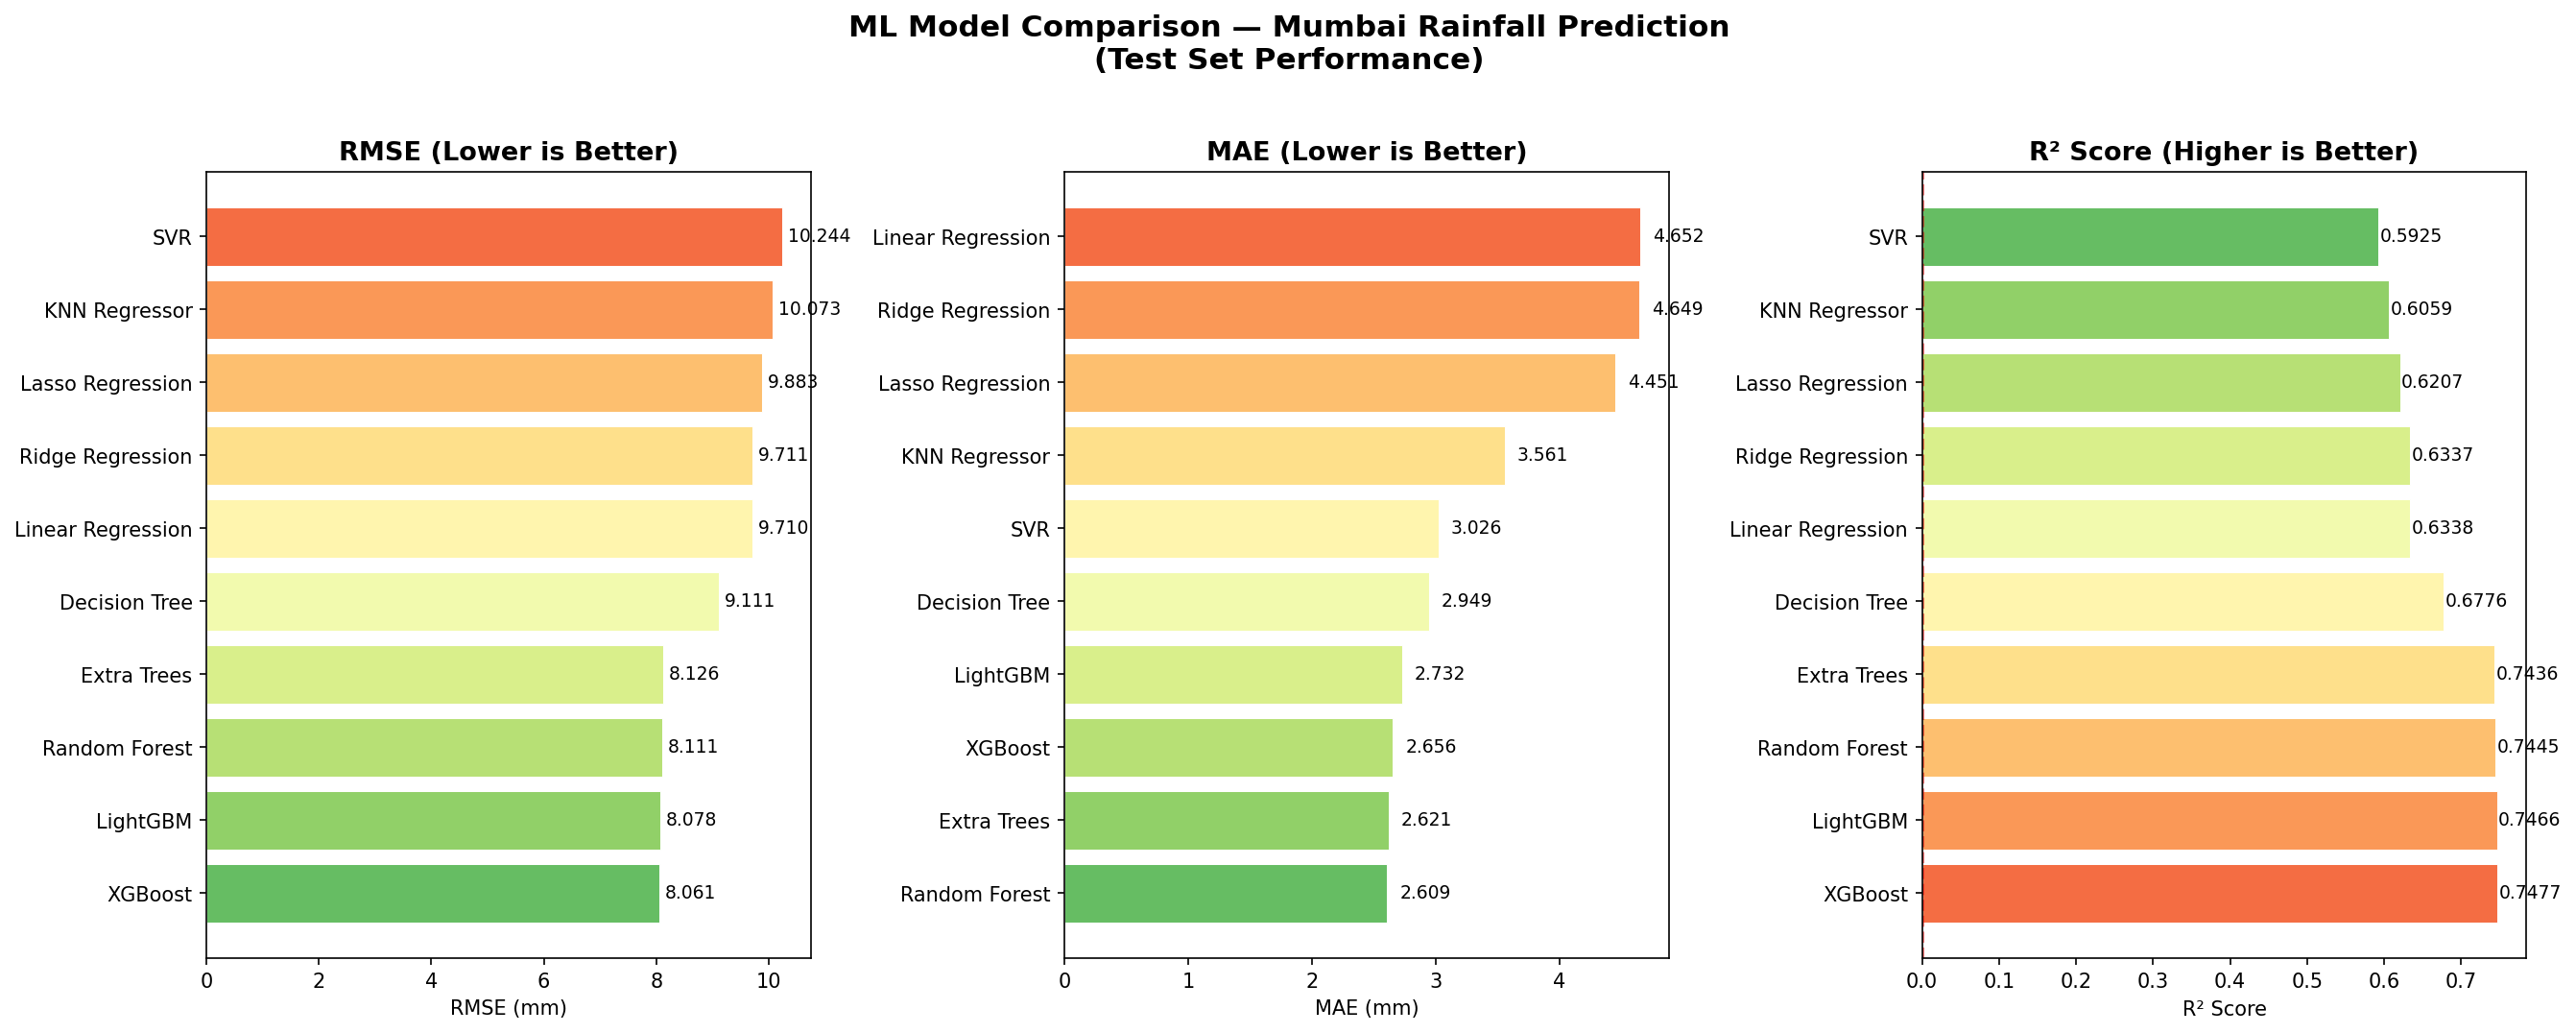

In [5]:
from IPython.display import Image, display

display(Image("../reports/figures/model_comparison.png"))

In [6]:
shap_fi = pd.read_csv("../reports/shap_feature_importance.csv")

print("="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)

display(shap_fi.head(10))

print("\nInterpretation")

print("- Evapotranspiration had the highest overall influence on rainfall prediction.")
print("- Yesterday's rainfall (lag_1) is one of the strongest predictors, showing rainfall persistence.")
print("- Rolling rainfall statistics capture short-term rainfall trends.")
print("- Wind speed, humidity and cloud cover also contribute to rainfall prediction.")
print("- Seasonal features help the model recognize annual weather cycles.")

TOP 10 MOST IMPORTANT FEATURES


,feature,mean_abs_shap
0,evapotranspiration_mm,3.713150
1,precipitation_mm_lag_1,2.146752
2,precipitation_mm_rolling_std_7d,1.340060
3,precipitation_mm_rolling_sum_7d,0.479431
4,wind_speed_max_kmh,0.346865
5,precipitation_mm_rolling_mean_7d,0.326598
6,humidity_min_pct,0.270698
7,doy_cos,0.218352
8,cloud_cover_pct,0.177784
9,temp_min_c,0.154252



Interpretation
- Evapotranspiration had the highest overall influence on rainfall prediction.
- Yesterday's rainfall (lag_1) is one of the strongest predictors, showing rainfall persistence.
- Rolling rainfall statistics capture short-term rainfall trends.
- Wind speed, humidity and cloud cover also contribute to rainfall prediction.
- Seasonal features help the model recognize annual weather cycles.


In [7]:
print("="*60)
print("MULTI-CITY PERFORMANCE")
print("="*60)

display(
    multi_city.sort_values("Test_RMSE")
)

print("\nObservations")

print("- Jaipur achieved the lowest RMSE.")
print("- Mumbai achieved the highest R² but also the highest RMSE because rainfall is much more variable.")
print("- Coastal cities generally have larger rainfall variability.")
print("- The XGBoost model generalized well across all six cities.")

MULTI-CITY PERFORMANCE


,City,Annual_Rainfall_mm,Test_MAE,Test_RMSE,Test_R2,Train_Samples,Test_Samples
0,Jaipur,546.0,1.117,3.471,0.6853,10203,2551
1,Bengaluru,936.0,1.883,3.733,0.5821,10203,2551
2,Delhi,693.0,1.234,3.813,0.7016,10203,2551
3,Kolkata,1673.0,2.655,5.554,0.6650,10203,2551
4,Chennai,1058.0,2.004,6.244,0.6572,10203,2551
5,Mumbai,1975.0,2.831,8.362,0.7284,10203,2551



Observations
- Jaipur achieved the lowest RMSE.
- Mumbai achieved the highest R² but also the highest RMSE because rainfall is much more variable.
- Coastal cities generally have larger rainfall variability.
- The XGBoost model generalized well across all six cities.


In [8]:
observations = """
WEEK 2 KEY LEARNINGS
====================

1. Machine Learning Models
--------------------------
Tree-based models (XGBoost, Random Forest and LightGBM) consistently
outperformed linear regression models for rainfall prediction.
XGBoost achieved the best overall performance with the lowest test RMSE
and highest predictive accuracy.

2. SHAP Explainability
----------------------
SHAP analysis showed that evapotranspiration, previous day's rainfall
(lag_1), rolling rainfall statistics, wind speed and cloud cover were
among the most influential features. This demonstrates that both recent
weather conditions and atmospheric variables strongly affect rainfall.

3. Time Series Models
---------------------
Both Prophet and SARIMA successfully captured long-term seasonal rainfall
patterns. Prophet slightly outperformed SARIMA on the monthly rainfall
forecasting task, although the feature-based ML models remained more
effective for daily rainfall prediction.

4. Multi-City Analysis
----------------------
The XGBoost model generalized well across all six cities.
Jaipur recorded the lowest prediction error, while Mumbai had the highest
RMSE due to its highly variable monsoon rainfall.

5. Overall Learning
-------------------
This week provided hands-on experience with baseline models, traditional
machine learning algorithms, explainable AI using SHAP, classical time
series forecasting and multi-city model evaluation. These experiments
established a strong baseline for the deep learning models planned for
the following week.

Next Week
---------
- Build LSTM-based rainfall prediction models.
- Compare deep learning models with XGBoost.
- Begin satellite imagery and climate intelligence analysis.
"""

print(observations)


WEEK 2 KEY LEARNINGS

1. Machine Learning Models
--------------------------
Tree-based models (XGBoost, Random Forest and LightGBM) consistently
outperformed linear regression models for rainfall prediction.
XGBoost achieved the best overall performance with the lowest test RMSE
and highest predictive accuracy.

2. SHAP Explainability
----------------------
SHAP analysis showed that evapotranspiration, previous day's rainfall
(lag_1), rolling rainfall statistics, wind speed and cloud cover were
among the most influential features. This demonstrates that both recent
weather conditions and atmospheric variables strongly affect rainfall.

3. Time Series Models
---------------------
Both Prophet and SARIMA successfully captured long-term seasonal rainfall
patterns. Prophet slightly outperformed SARIMA on the monthly rainfall
forecasting task, although the feature-based ML models remained more
effective for daily rainfall prediction.

4. Multi-City Analysis
----------------------
The XGBoo